
# Informe de análisis descriptivo multivariado

**Tablas analizadas:** T1.4 a T1.9

Este notebook presenta, para cada conjunto de datos:

- medidas de posición y dispersión;
- **exactamente 3 gráficas por tabla**;
- gráficas multivariadas de uso frecuente en análisis descriptivo;
- un comentario breve, en formato de informe.

Criterios aplicados en esta versión:

1. Se convierten explícitamente las variables numéricas a tipo numérico.
2. Cada tabla queda contenida en una función propia.
3. Todo se muestra al ejecutar las funciones, sin exportar imágenes ni carpetas.
4. Las elecciones gráficas se ajustan a la referencia del documento compartido, privilegiando matrices de dispersión, mapas de correlación, PCA y dispersión 3D, **excluyendo el gráfico de caras**.


In [41]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")


In [42]:

# =========================
# Utilidades generales
# =========================

def leer_tabla(path, columnas=None, sep=None, decimal=","):
    """
    Lee archivos .txt con separador por tabulación o espacios.
    Si no se especifica, intenta inferir el separador.
    """
    with open(path, "r", encoding="utf-8") as f:
        primera_linea = f.readline()

    if sep is None:
        sep = "\t" if "\t" in primera_linea else r"\s+"

    header = 0 if ("\t" in primera_linea and columnas is None and "company" in primera_linea.lower()) else None

    df = pd.read_csv(
        path,
        sep=sep,
        engine="python",
        header=header,
        decimal=decimal
    )

    if columnas is not None:
        df.columns = columnas

    return df


def convertir_numericas(df, excluir=None):
    """
    Convierte columnas no excluidas a numéricas.
    Maneja comas decimales, strings con espacios y valores faltantes.
    """
    if excluir is None:
        excluir = []

    out = df.copy()

    for col in out.columns:
        if col in excluir:
            continue

        if out[col].dtype == "O":
            out[col] = (
                out[col]
                .astype(str)
                .str.strip()
                .str.replace(",", ".", regex=False)
            )

        out[col] = pd.to_numeric(out[col])
        

    return out


def columnas_numericas(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()


def resumen_descriptivo(df):
    num = df[columnas_numericas(df)]
    res = pd.DataFrame({
        "Media": num.mean(),
        "Mediana": num.median(),
        "Desv.Std": num.std(),
        "CV_%": (num.std() / num.mean().replace(0, np.nan)) * 100,
        "Min": num.min(),
        "Q1": num.quantile(0.25),
        "Q3": num.quantile(0.75),
        "Max": num.max(),
        "IQR": num.quantile(0.75) - num.quantile(0.25)
    })
    return res.round(3)


def outliers_iqr(df):
    num = df[columnas_numericas(df)]
    q1 = num.quantile(0.25)
    q3 = num.quantile(0.75)
    iqr = q3 - q1
    mask = (num < (q1 - 1.5 * iqr)) | (num > (q3 + 1.5 * iqr))
    return mask, mask.sum(axis=1)


def top_correlaciones(df, n=3):
    num = df[columnas_numericas(df)]
    corr = num.corr()
    pares = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pares.append((cols[i], cols[j], corr.iloc[i, j]))
    pares = sorted(pares, key=lambda x: abs(x[2]), reverse=True)
    return pares[:n], corr


def pca_dataframe(df, cols=None):
    if cols is None:
        cols = columnas_numericas(df)
    X = df[cols].copy()
    Z = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(Z)
    coords = pd.DataFrame(coords, columns=["PC1", "PC2"], index=df.index)
    return coords, pca

# =========================
# Gráficas base
# =========================

def grafico_correlacion(df, titulo, cols=None):
    if cols is None:
        cols = columnas_numericas(df)
    corr = df[cols].corr()
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title(f"{titulo} - Mapa de correlaciones")
    plt.tight_layout()
    plt.show()


def grafico_pairplot(df, titulo, cols=None, hue=None, max_cols=5):
    if cols is None:
        cols = columnas_numericas(df)
    cols = cols[:max_cols]
    data = df[cols].copy()
    if hue is not None and hue in df.columns:
        data[hue] = df[hue].astype(str)
    g = sns.pairplot(data, hue=hue if hue in data.columns else None, diag_kind="hist", corner=False)
    g.fig.suptitle(f"{titulo} - Matriz de dispersión", y=1.02)
    plt.show()


def grafico_pca(df, titulo, cols=None, hue=None, labels=None):
    if cols is None:
        cols = columnas_numericas(df)
    coords, pca = pca_dataframe(df, cols=cols)

    plt.figure(figsize=(8, 6))
    if hue is not None and hue in df.columns:
        grupos = df[hue].astype(str)
        for g in sorted(grupos.unique()):
            m = grupos == g
            plt.scatter(coords.loc[m, "PC1"], coords.loc[m, "PC2"], alpha=0.8, label=str(g))
        plt.legend(title=hue)
    else:
        plt.scatter(coords["PC1"], coords["PC2"], alpha=0.8)

    if labels is not None:
        for idx, lab in labels.items():
            plt.annotate(str(lab), (coords.loc[idx, "PC1"], coords.loc[idx, "PC2"]), fontsize=8, alpha=0.85)

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title(f"{titulo} - PCA")
    plt.tight_layout()
    plt.show()


def grafico_burbujas(df, x, y, size, titulo, label_col=None):
    plt.figure(figsize=(8, 6))
    s = (df[size] / df[size].max()) * 2500 + 100
    plt.scatter(df[x], df[y], s=s, alpha=0.6)
    if label_col is not None:
        for _, row in df.iterrows():
            plt.annotate(str(row[label_col]).replace("_", " "), (row[x], row[y]), fontsize=8)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()


def grafico_parallel(df, titulo, cols=None, grupo_col=None):
    if cols is None:
        cols = columnas_numericas(df)
    z = pd.DataFrame(StandardScaler().fit_transform(df[cols]), columns=cols, index=df.index)
    clase = grupo_col if grupo_col is not None and grupo_col in df.columns else "_grupo"
    if clase == "_grupo":
        z[clase] = "Obs"
    else:
        z[clase] = df[grupo_col].astype(str).values

    plt.figure(figsize=(10, 5))
    parallel_coordinates(z, clase, alpha=0.35)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{titulo} - Coordenadas paralelas estandarizadas")
    plt.tight_layout()
    plt.show()


def grafico_3d(df, x, y, z, titulo):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(df[x], df[y], df[z], alpha=0.8)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


In [43]:

ARCHIVOS = {
    "T1_5": "T1.5.txt",
    "T1_6": "T1.6.txt",
    "T1_4": "T1.4.txt",
    "T1_7": "T1.7.txt",
    "T1_8": "T1.8.txt",
    "T1_9": "T1.9.txt",
}


In [44]:

# =========================
# Funciones por tabla
# =========================

def analizar_tabla_14():
    display(Markdown("## Tabla 1.4 – The World’s 10 Largest Companies"))
    df = leer_tabla(ARCHIVOS["T1_4"], sep="\t", decimal=",")
    df = convertir_numericas(df, excluir=["company"])
    df = df.rename(columns={"company": "Empresa", "sales": "Ventas", "profits": "Utilidades", "assets": "Activos"})

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    display(Markdown("### Gráfica 1 de 3: burbujas"))
    grafico_burbujas(df, "Ventas", "Utilidades", "Activos", "Tabla 1.4 - Ventas vs Utilidades (tamaño = Activos)", label_col="Empresa")

    display(Markdown("### Gráfica 2 de 3: correlaciones"))
    grafico_correlacion(df, "Tabla 1.4", cols=["Ventas", "Utilidades", "Activos"])

    display(Markdown("### Gráfica 3 de 3: PCA"))
    grafico_pca(df, "Tabla 1.4", cols=["Ventas", "Utilidades", "Activos"], labels=df["Empresa"].to_dict())

def analizar_tabla_15():
    display(Markdown("## Tabla 1.5 – Air-Pollution Data"))
    columnas = ["Wind", "Radiation", "CO", "NO", "NO2", "O3", "HC"]
    df = leer_tabla(ARCHIVOS["T1_5"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    display(Markdown("### Gráfica 1 de 3: matriz de dispersión"))
    grafico_pairplot(df, "Tabla 1.5", cols=["Wind", "Radiation", "CO", "NO", "NO2", "O3"], max_cols=6)

    display(Markdown("### Gráfica 2 de 3: correlaciones"))
    grafico_correlacion(df, "Tabla 1.5", cols=columnas)

    display(Markdown("### Gráfica 3 de 3: PCA"))
    grafico_pca(df, "Tabla 1.5", cols=columnas)


def analizar_tabla_16():
    display(Markdown("## Tabla 1.6 – Multiple-Sclerosis Data"))
    columnas = ["age", "x2", "x3", "x4", "x5", "grupos"]
    df = leer_tabla(ARCHIVOS["T1_6"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)
    df["grupos"] = df["grupos"].map({0: "Control", 1: "Esclerosis"}).fillna(df["grupos"].astype(str))

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    vars_num = ["age", "x2", "x3", "x4", "x5"]

    display(Markdown("### Gráfica 1 de 3: matriz de dispersión por grupo"))
    grafico_pairplot(df, "Tabla 1.6", cols=vars_num, hue="grupos", max_cols=5)

    display(Markdown("### Gráfica 2 de 3: correlaciones"))
    grafico_correlacion(df, "Tabla 1.6", cols=vars_num)

    display(Markdown("### Gráfica 3 de 3: PCA por grupo"))
    grafico_pca(df, "Tabla 1.6", cols=vars_num, hue="grupos")

def analizar_tabla_17():
    display(Markdown("## Tabla 1.7 – Radiotherapy Data"))
    columnas = ["symptoms", "activity", "sleep", "eat", "appetite", "skin_reaction"]
    df = leer_tabla(ARCHIVOS["T1_7"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)
    df["skin_reaction"] = df["skin_reaction"].astype(int).astype(str)

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    vars_num = ["symptoms", "activity", "sleep", "eat", "appetite"]

    display(Markdown("### Gráfica 1 de 3: matriz de dispersión"))
    grafico_pairplot(df, "Tabla 1.7", cols=vars_num, hue="skin_reaction", max_cols=5)

    display(Markdown("### Gráfica 2 de 3: correlaciones"))
    grafico_correlacion(df, "Tabla 1.7", cols=["symptoms", "activity", "sleep", "eat", "appetite", "skin_reaction"])

    display(Markdown("### Gráfica 3 de 3: PCA"))
    grafico_pca(df, "Tabla 1.7", cols=vars_num, hue="skin_reaction")


def analizar_tabla_18():
    display(Markdown("## Tabla 1.8 – Mineral Content in Bones"))
    columnas = ["dominant_radius", "radius", "dominant_humerus", "humerus", "dominant_ulna", "ulna"]
    df = leer_tabla(ARCHIVOS["T1_8"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    display(Markdown("### Gráfica 1 de 3: correlaciones"))
    grafico_correlacion(df, "Tabla 1.8", cols=columnas)

    display(Markdown("### Gráfica 2 de 3: dispersión 3D lado dominante"))
    grafico_3d(df, "dominant_radius", "dominant_humerus", "dominant_ulna", "Tabla 1.8 - Lado dominante")

    display(Markdown("### Gráfica 3 de 3: dispersión 3D lado no dominante"))
    grafico_3d(df, "radius", "humerus", "ulna", "Tabla 1.8 - Lado no dominante")

def analizar_tabla_19():
    display(Markdown("## Tabla 1.9 – National Track Records for Women"))
    columnas = ["country", "100_m", "200_m", "400_m", "800_m", "1500_m", "3000_m", "marathon"]
    df = leer_tabla(ARCHIVOS["T1_9"], columnas=columnas, decimal=".")
    df = convertir_numericas(df, excluir=["country"])

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    display(Markdown("### Gráfica 1 de 3: correlaciones"))
    grafico_correlacion(df, "Tabla 1.9", cols=columnas[1:])

    display(Markdown("### Gráfica 2 de 3: PCA con países"))
    grafico_pca(df, "Tabla 1.9", cols=columnas[1:], labels=df["country"].to_dict())

    display(Markdown("### Gráfica 3 de 3: coordenadas paralelas"))
    grafico_parallel(df, "Tabla 1.9", cols=columnas[1:])

def ejecutar_todo():
    analizar_tabla_14()
    analizar_tabla_15()
    analizar_tabla_16()
    analizar_tabla_17()
    analizar_tabla_18()
    analizar_tabla_19()


## Tabla 1.4 – The World’s 10 Largest Companies

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
Ventas,155.603,130.320,86.466,55.569,62.97,92.768,239.413,285.06,146.645
Utilidades,14.704,14.935,5.118,34.804,8.10,10.965,16.935,25.33,5.970
Activos,710.911,758.375,486.882,68.487,191.11,199.232,1090.668,1484.10,891.435


### Gráfica 1 de 3: burbujas

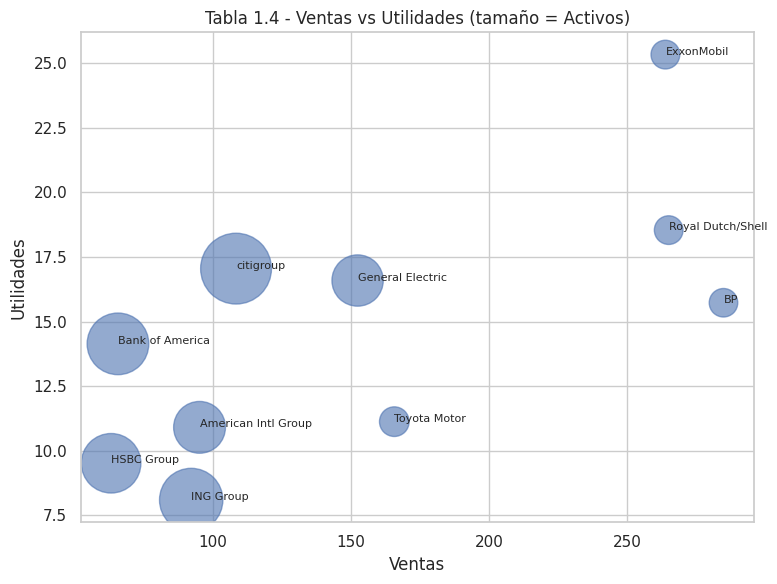

### Gráfica 2 de 3: correlaciones

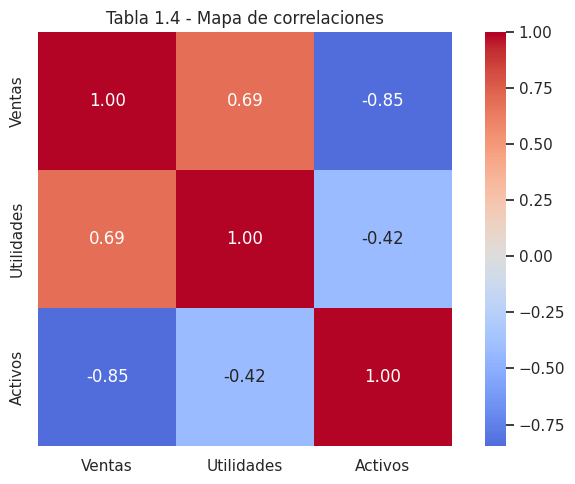

### Gráfica 3 de 3: PCA

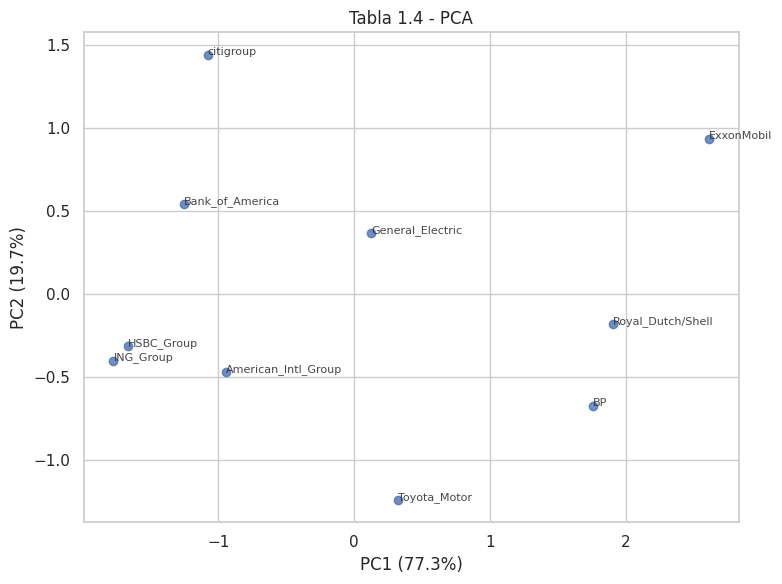

## Tabla 1.5 – Air-Pollution Data

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
Wind,7.500,8.0,1.581,21.082,5,6.00,8.75,10,2.75
Radiation,73.857,76.5,17.335,23.472,30,68.25,84.75,107,16.50
CO,4.548,4.0,1.234,27.129,2,4.00,5.00,7,1.00
NO,2.190,2.0,1.087,49.640,1,1.00,3.00,5,2.00
NO2,10.048,9.5,3.371,33.550,5,8.00,12.00,21,4.00
O3,9.405,8.5,5.566,59.181,2,6.00,11.00,25,5.00
HC,3.095,3.0,0.692,22.349,2,3.00,3.00,5,0.00


### Gráfica 1 de 3: matriz de dispersión

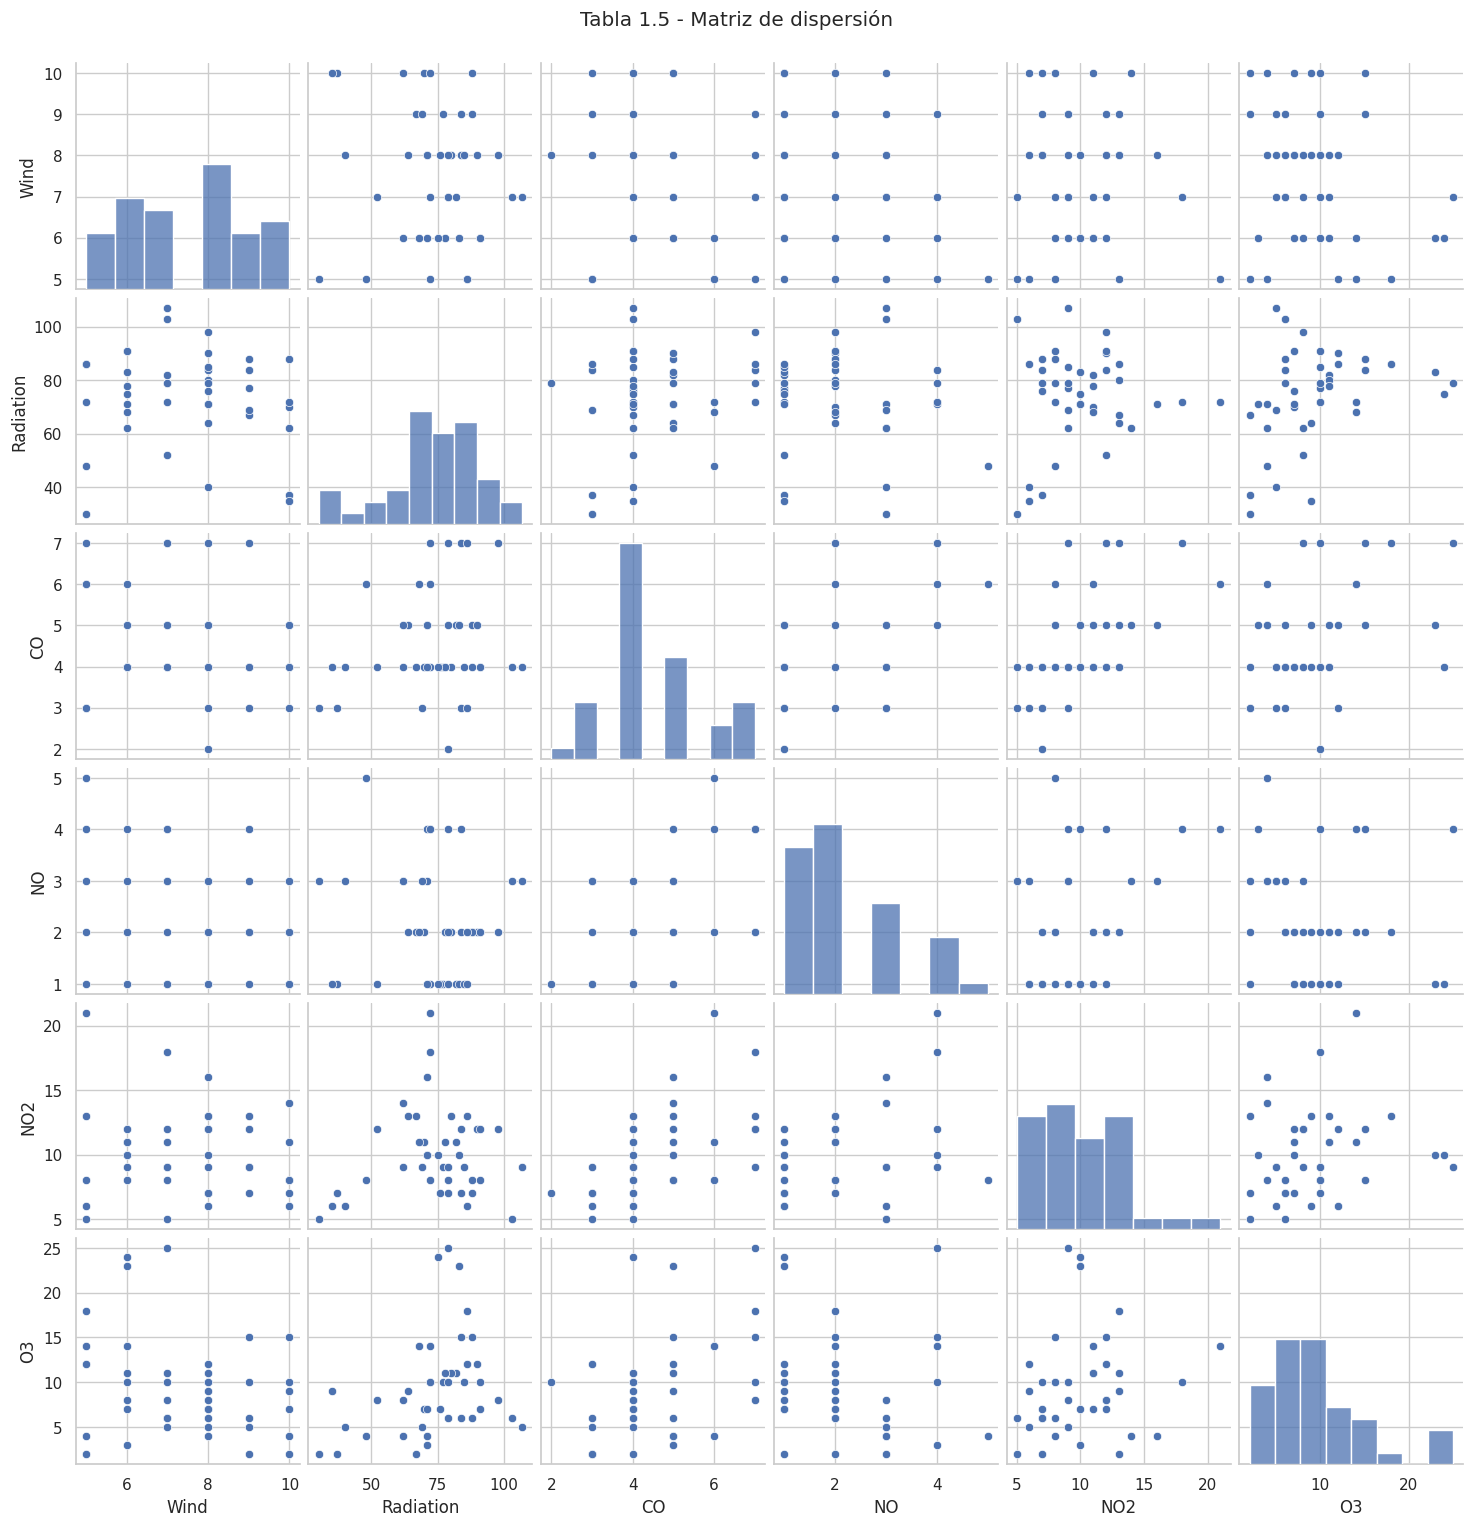

### Gráfica 2 de 3: correlaciones

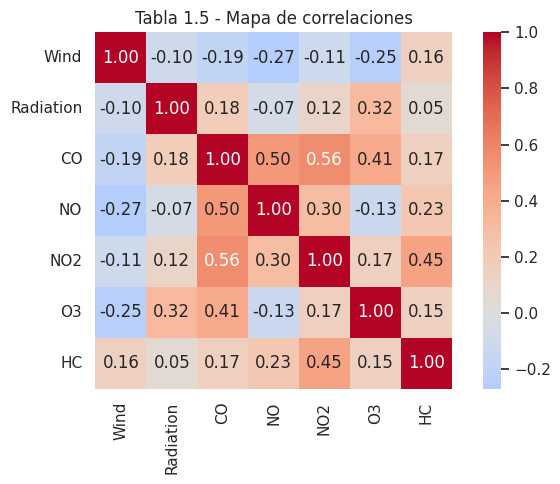

### Gráfica 3 de 3: PCA

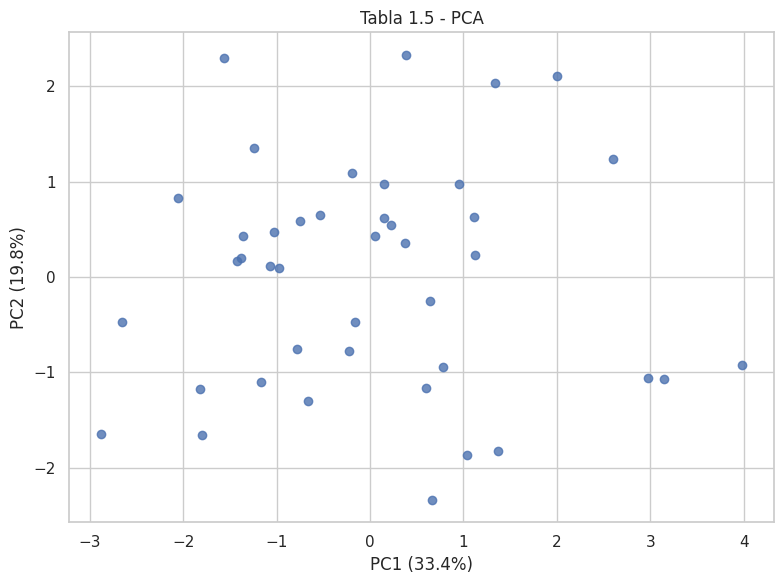

## Tabla 1.6 – Multiple-Sclerosis Data

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
age,39.194,36.0,15.268,38.955,18.0,25.25,49.75,79.0,24.50
x2,156.457,148.8,22.903,14.639,125.4,141.45,162.90,238.4,21.45
x3,4.733,1.6,10.817,228.561,0.0,0.80,3.35,90.2,2.55
x4,207.833,200.6,28.810,13.862,169.2,188.20,217.40,328.0,29.20
x5,5.012,1.6,11.430,228.039,0.0,0.40,3.35,83.0,2.95


### Gráfica 1 de 3: matriz de dispersión por grupo

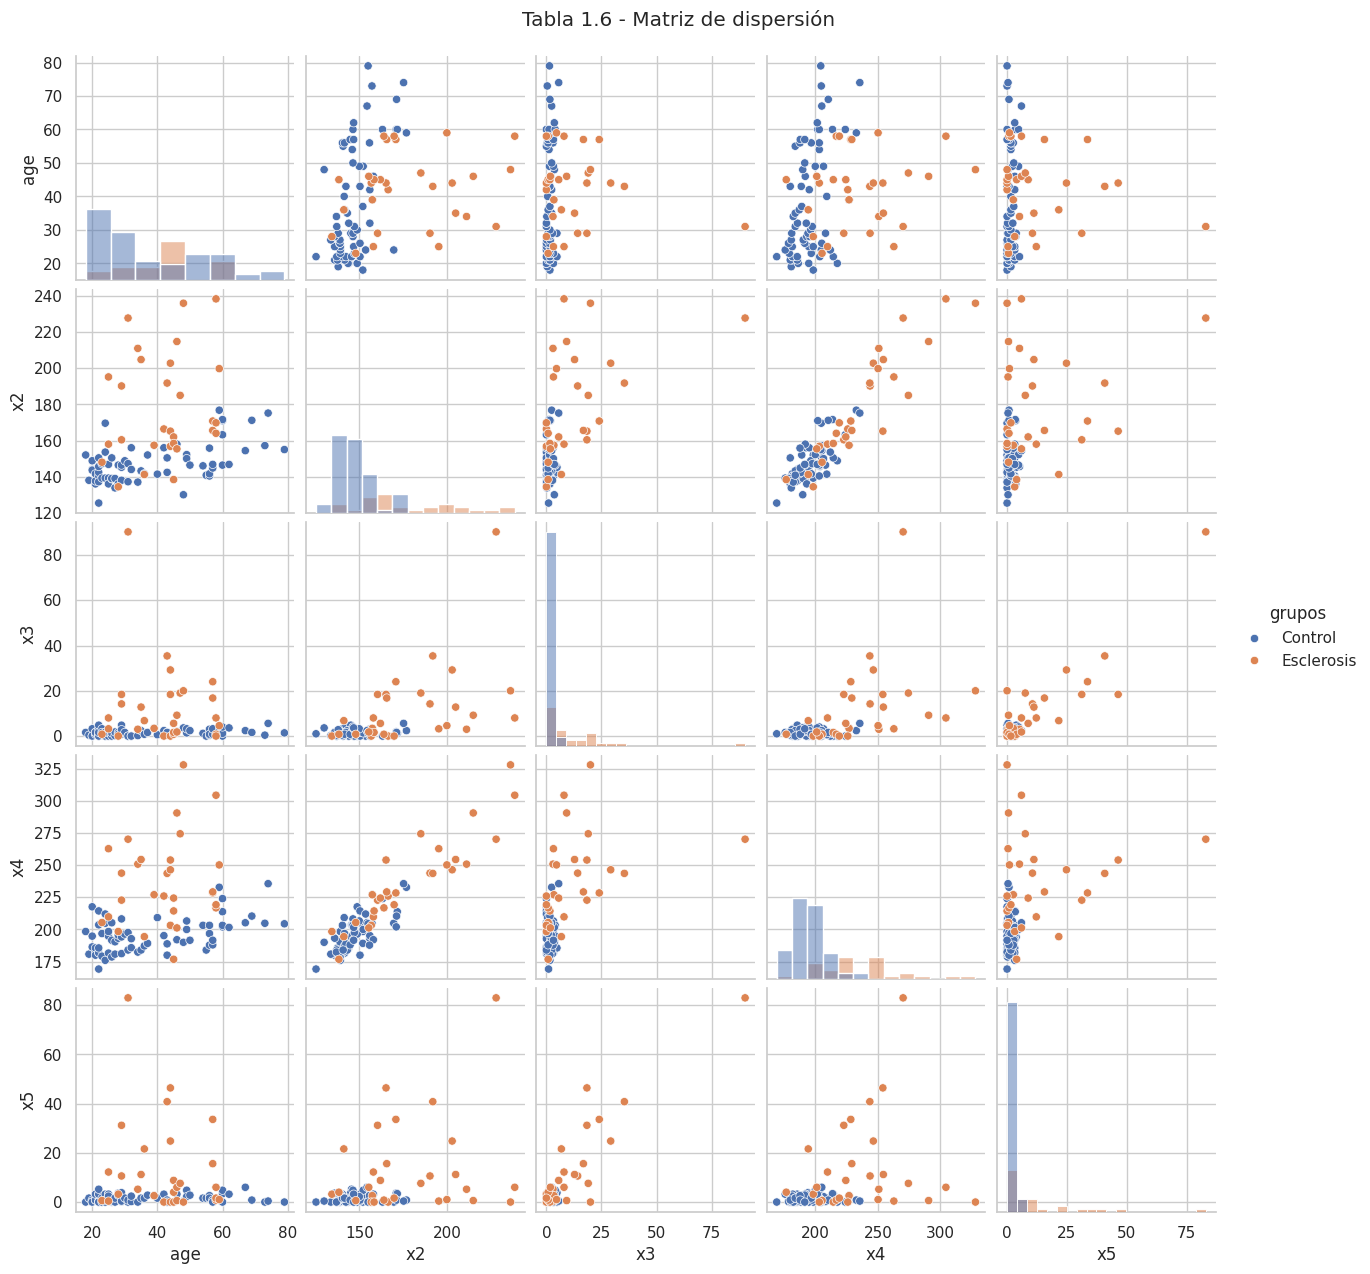

### Gráfica 2 de 3: correlaciones

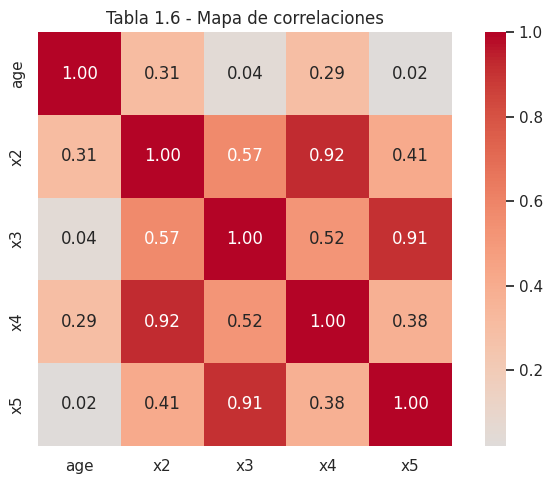

### Gráfica 3 de 3: PCA por grupo

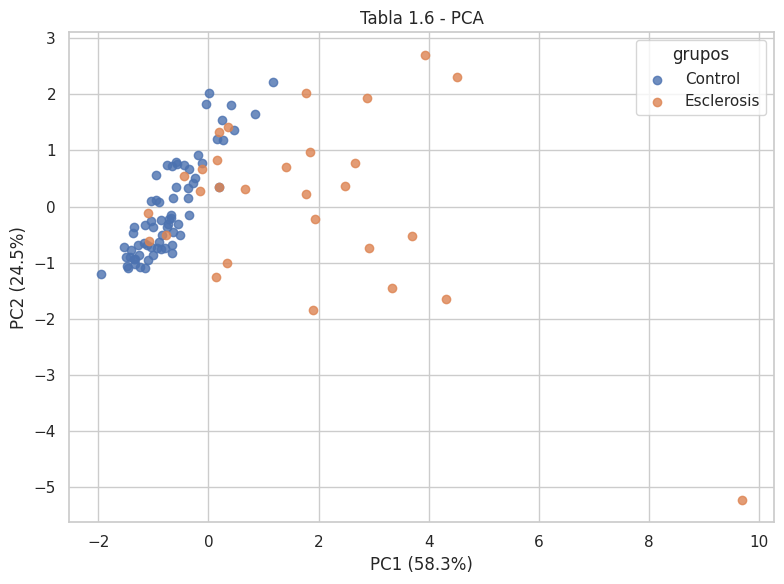

## Tabla 1.7 – Radiotherapy Data

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
symptoms,3.542,3.404,2.157,60.906,0.000,1.887,5.178,10.461,3.291
activity,1.809,1.641,0.783,43.266,0.941,1.111,2.323,4.000,1.212
sleep,2.138,2.178,0.756,35.363,0.666,1.564,2.712,4.000,1.148
eat,2.209,2.140,0.332,15.042,1.286,2.000,2.440,2.937,0.440
appetite,2.575,2.500,0.929,36.062,1.000,1.924,3.272,5.000,1.348


### Gráfica 1 de 3: matriz de dispersión

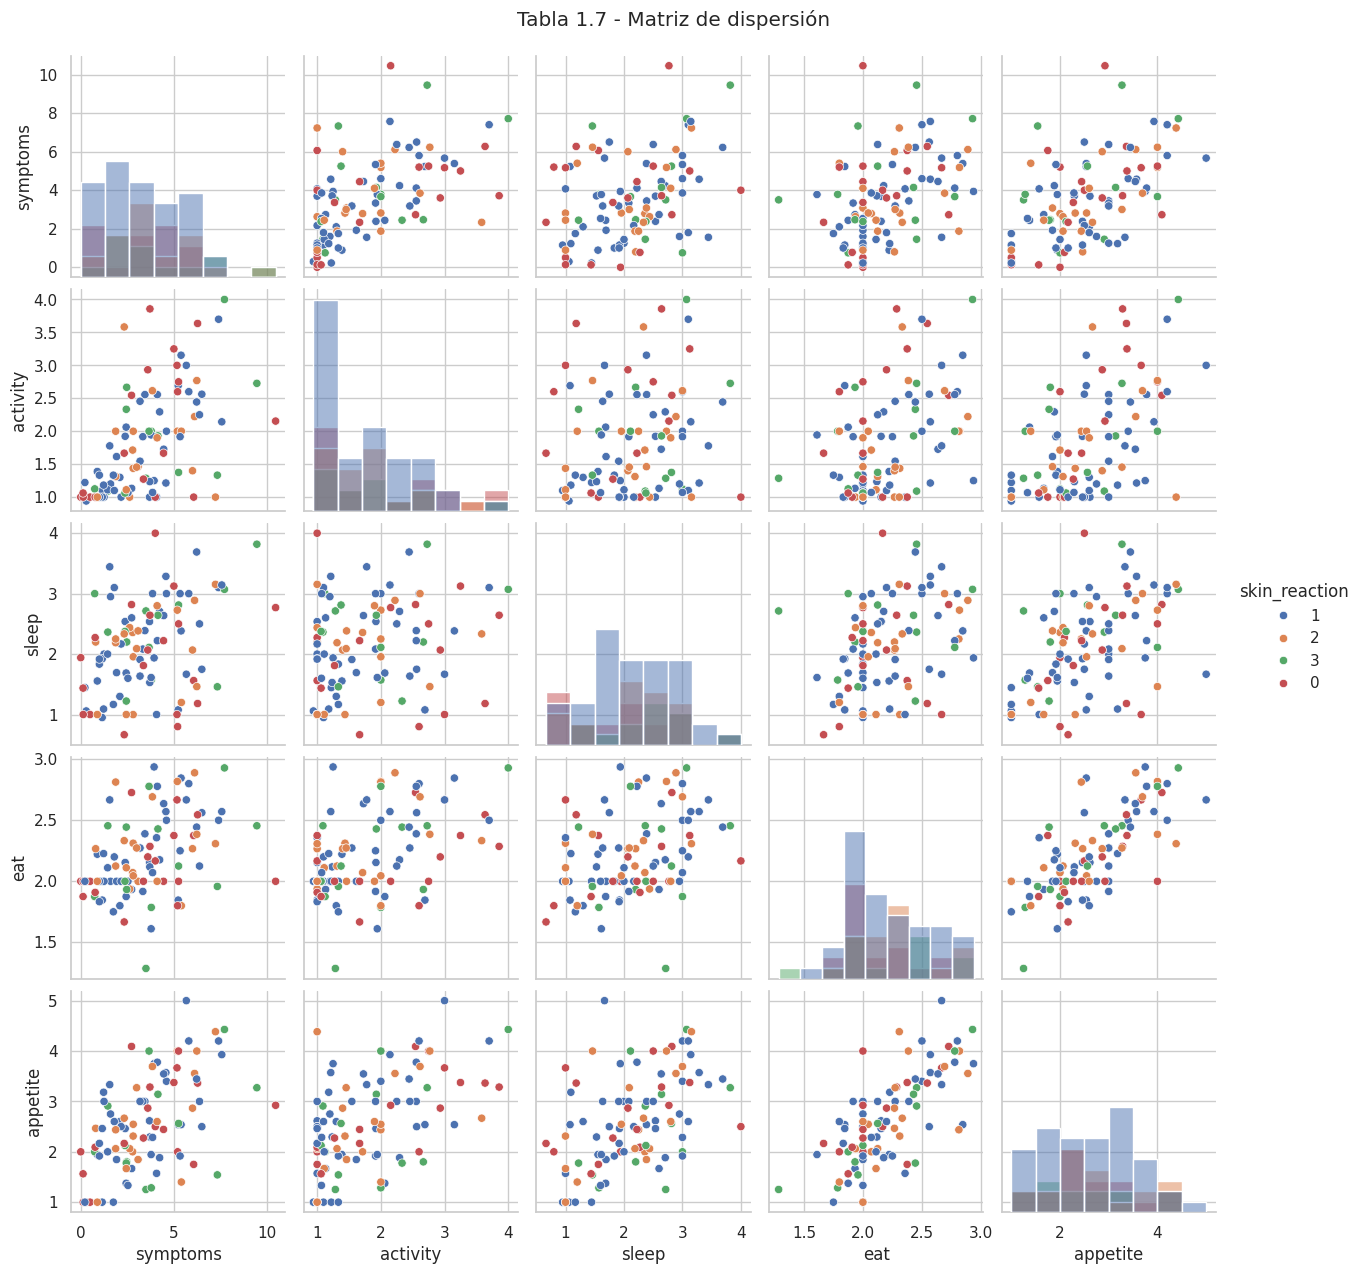

### Gráfica 2 de 3: correlaciones

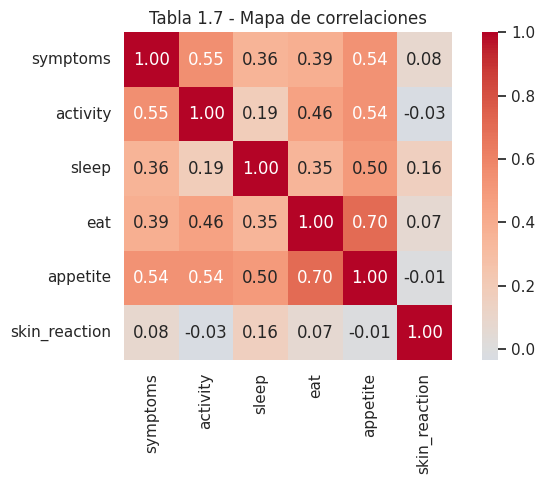

### Gráfica 3 de 3: PCA

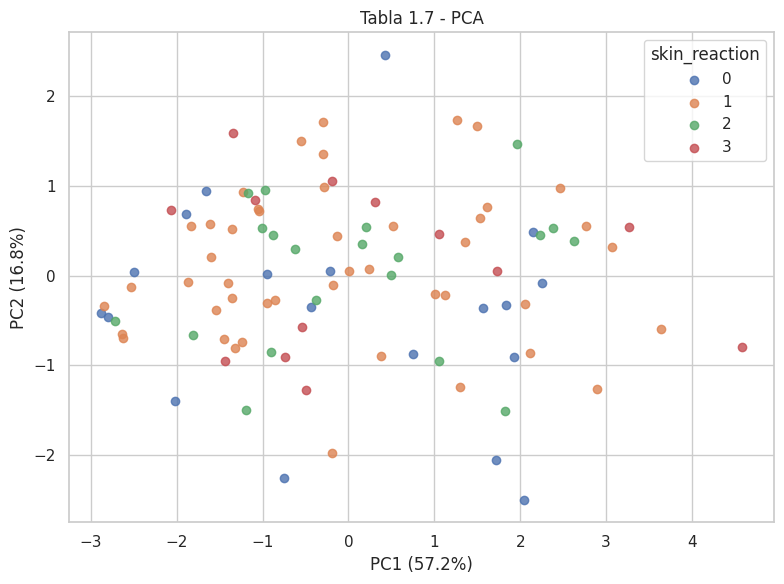

## Tabla 1.8 – Mineral Content in Bones

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
dominant_radius,0.844,0.856,0.114,13.513,0.493,0.792,0.921,1.103,0.129
radius,0.818,0.838,0.107,13.058,0.532,0.752,0.876,1.052,0.124
dominant_humerus,1.793,1.786,0.283,15.813,1.037,1.650,1.954,2.334,0.304
humerus,1.735,1.759,0.264,15.194,1.268,1.547,1.869,2.238,0.322
dominant_ulna,0.704,0.706,0.108,15.269,0.533,0.618,0.782,0.873,0.164
ulna,0.694,0.682,0.103,14.838,0.482,0.615,0.765,0.872,0.150


### Gráfica 1 de 3: correlaciones

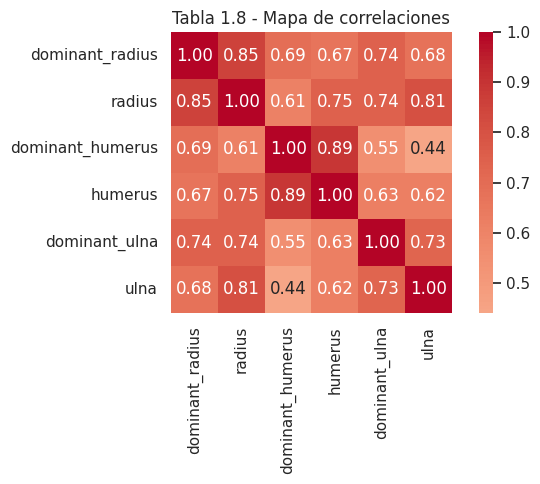

### Gráfica 2 de 3: dispersión 3D lado dominante

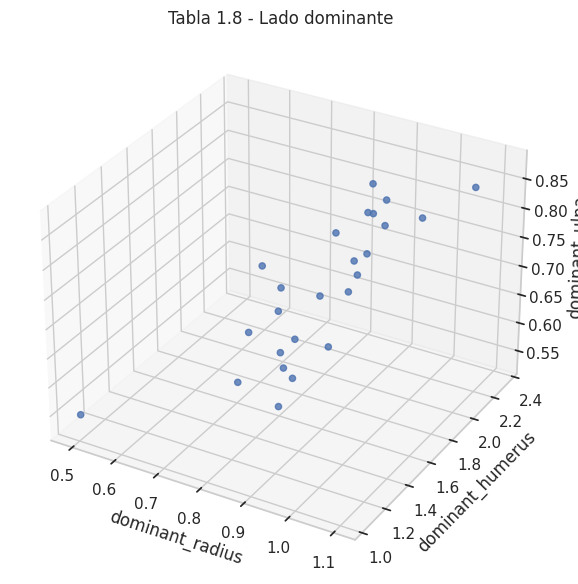

### Gráfica 3 de 3: dispersión 3D lado no dominante

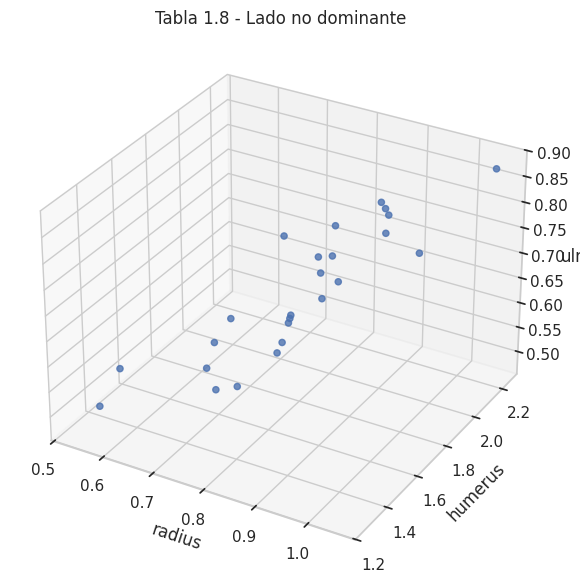

## Tabla 1.9 – National Track Records for Women

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
100_m,11.358,11.325,0.394,3.470,10.49,11.122,11.568,12.52,0.445
200_m,23.119,22.980,0.929,4.019,21.34,22.570,23.610,25.91,1.040
400_m,51.989,51.645,2.597,4.996,47.60,49.968,53.118,61.65,3.150
800_m,2.022,2.005,0.087,4.296,1.89,1.970,2.070,2.29,0.100
1500_m,4.189,4.100,0.272,6.501,3.84,4.002,4.338,5.42,0.335
3000_m,9.081,8.845,0.815,8.979,8.10,8.542,9.325,13.12,0.782
marathon,153.619,148.430,16.440,10.702,135.25,143.480,157.665,221.14,14.185


### Gráfica 1 de 3: correlaciones

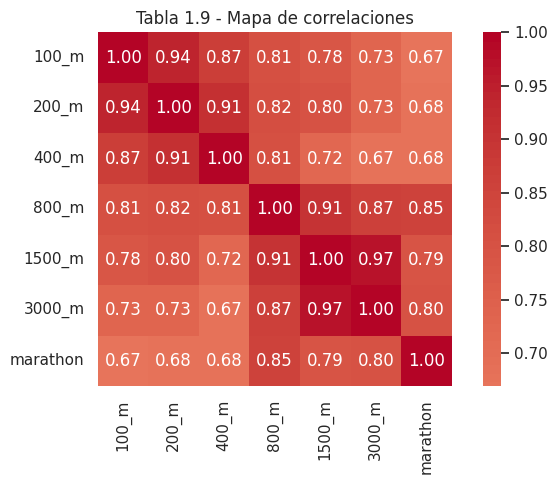

### Gráfica 2 de 3: PCA con países

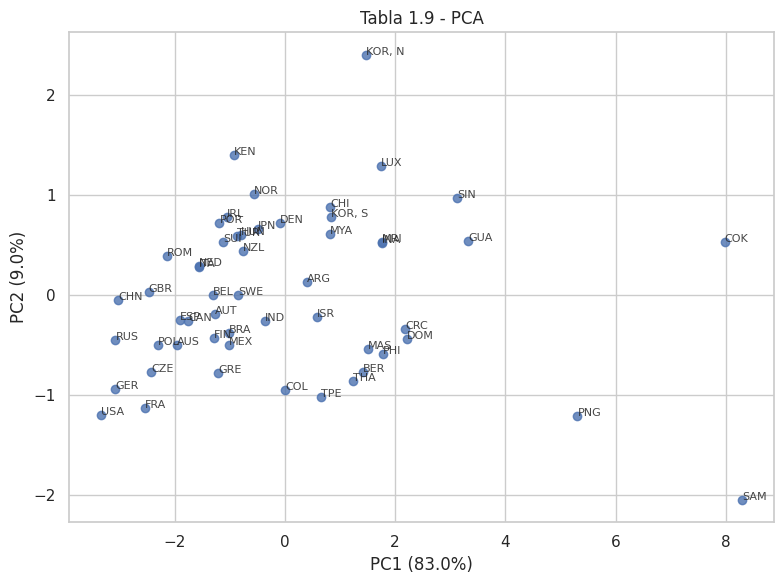

### Gráfica 3 de 3: coordenadas paralelas

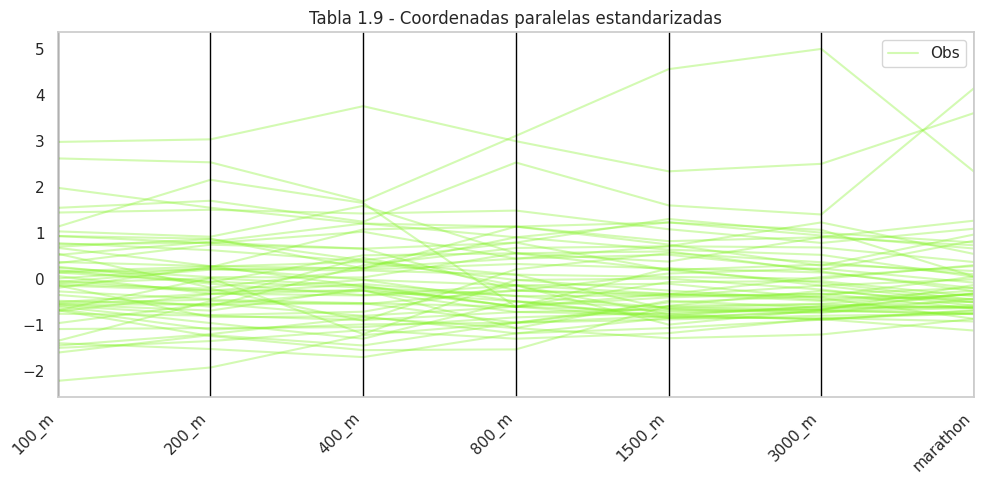

In [45]:
ejecutar_todo()

## Tabla 1.4 – The World’s 10 Largest Companies

### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Min,Q1,Q3,Max,IQR
Ventas,155.603,130.320,86.466,55.569,62.97,92.768,239.413,285.06,146.645
Utilidades,14.704,14.935,5.118,34.804,8.10,10.965,16.935,25.33,5.970
Activos,710.911,758.375,486.882,68.487,191.11,199.232,1090.668,1484.10,891.435


### Gráfica 1 de 3: burbujas

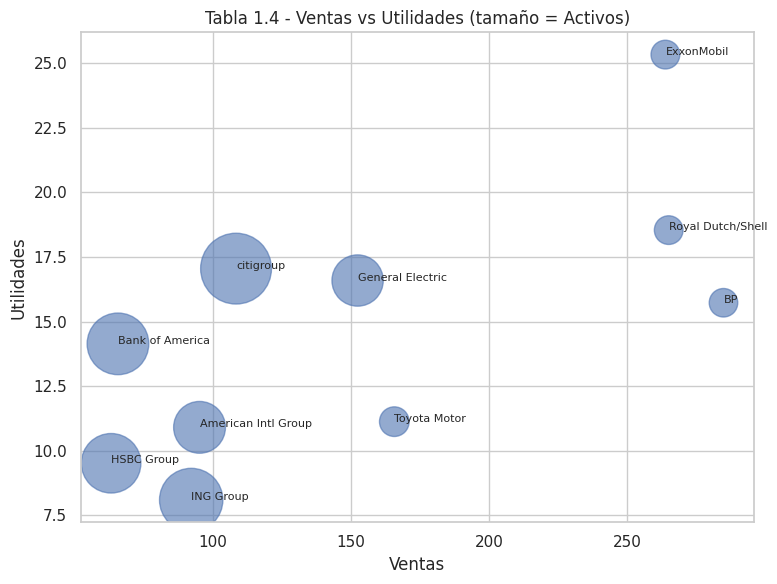

### Gráfica 2 de 3: correlaciones

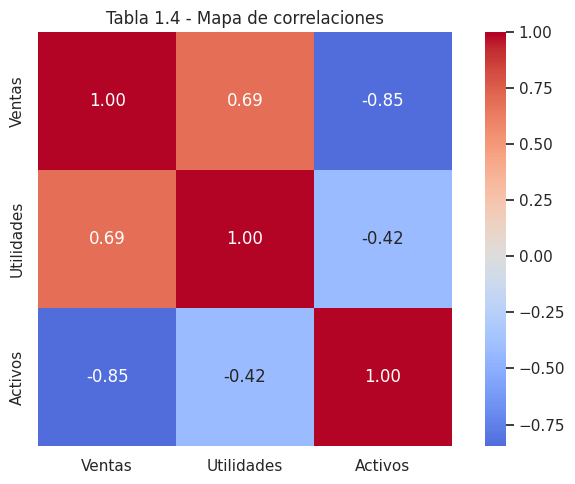

### Gráfica 3 de 3: PCA

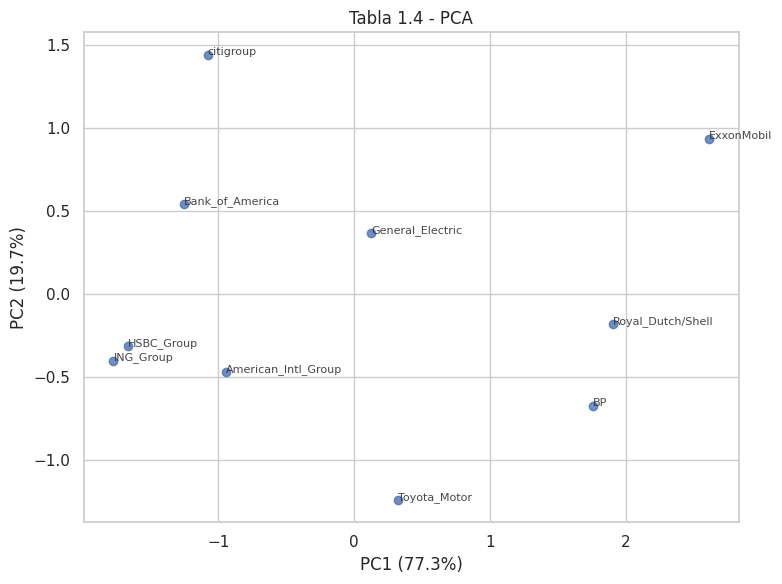

In [46]:
analizar_tabla_14()